<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de los algoritmos epsilon-greedy, epsilon-decaimiento, UCB1, UCB2 y softmax estudiados en sus respectivos nootbooks.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/06


## Preparación del entorno


In [2]:
#@title Copiar el repositorio.

#git clone https://github.com/ldaniel-hm/eml_k_bandit.git
#!cd eml_k_bandit/

In [3]:
#@title Importamos todas las clases y funciones

#import sys

# Añadir los directorio fuentes al path de Python
#sys.path.append('/content/eml_k_bandit')


# Verificar que se han añadido correctamente
#print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecaimiento, UCB1, UCB2, Softmax

from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret


## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

In [4]:
from utils import run_experiment

## Ejecución del experimento

Se realiza un experimento, utilizando una distribución de probabilidad normal con media $\mu\in[1,10]$ y desviación típica $\sigma=1$ de las recompensas asociadas a cada brazo. 

Se utiliza un bandido de 10 brazos. Se realizan 500 ejecuciones, cada una de 1000 pasos de tiempo. Se comparan los cinco algoritmos estudiados: $\epsilon$-greedy con $\epsilon$ = 0.01; $\epsilon$-decaimiento con epsilon inicial $\epsilon_0=1.0$, tasa de decaimiento $\lambda_{decay}=0.01$, y epsilon mínimo $\epsilon_{min}=0.01$; UCB1 con $c$=1; UCB2 con $\alpha$=0.1; softmax con temperatura $\tau=0.1$ y haciendo pasada inicial.

In [5]:
import json

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Para trabajar en todos los experimentos con las mismas recompensas de cada brazo, generamos los valores de mu para cada brazo una sola vez y los reutilizamos en todos los experimentos.
mu_values = set()
while len(mu_values) < k:
    mu = np.random.uniform(1.0, 10.0) # Generar un valor de mu aleatorio entre 1.0 y 10.0
    mu = round(mu, 2)
    mu_values.add(mu)

mu_values = list(mu_values)

In [6]:
# Creación del bandit

bandit = Bandit(arms=ArmNormal.generate_arms_with_fixed_means(mu_values)) # Generar un bandido con k brazos de distribución normal
print(bandit)  # Imprimir la configuración del bandido

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon y un algoritmo epsilon-decaimiento.
algorithms = [EpsilonGreedy(k=k, epsilon=0.01), EpsilonDecaimiento(k=k, epsilon_0=1.0, lambda_decay=0.01, epsilon_min=0.01), UCB1(k=k, c=1), UCB2(k=k, alpha=0.1), Softmax(k=k, temperature=0.1, exploring=True)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


c:\Users\aaron\Documents\_Universidad_\_Asignaturas_\Postgrado\Máster IA\Prácticas\EML_Carrillo_Ibarrola_Palomar\k_brazos\src\algorithms\ucb2.py:72: RuntimeWarning: invalid value encountered in sqrt
  ucb_values[a] = mean_reward + np.sqrt(numerator / denominator)


En este experimento se genera un bandido de 10 brazos, cada uno con una distribución normal de media entre 1 y 10 y desviación típica 1. En esta instancia concreta, el brazo 8 resulta ser el óptimo, con una recompensa esperada de 9.56.

#### Visualización de los resultados

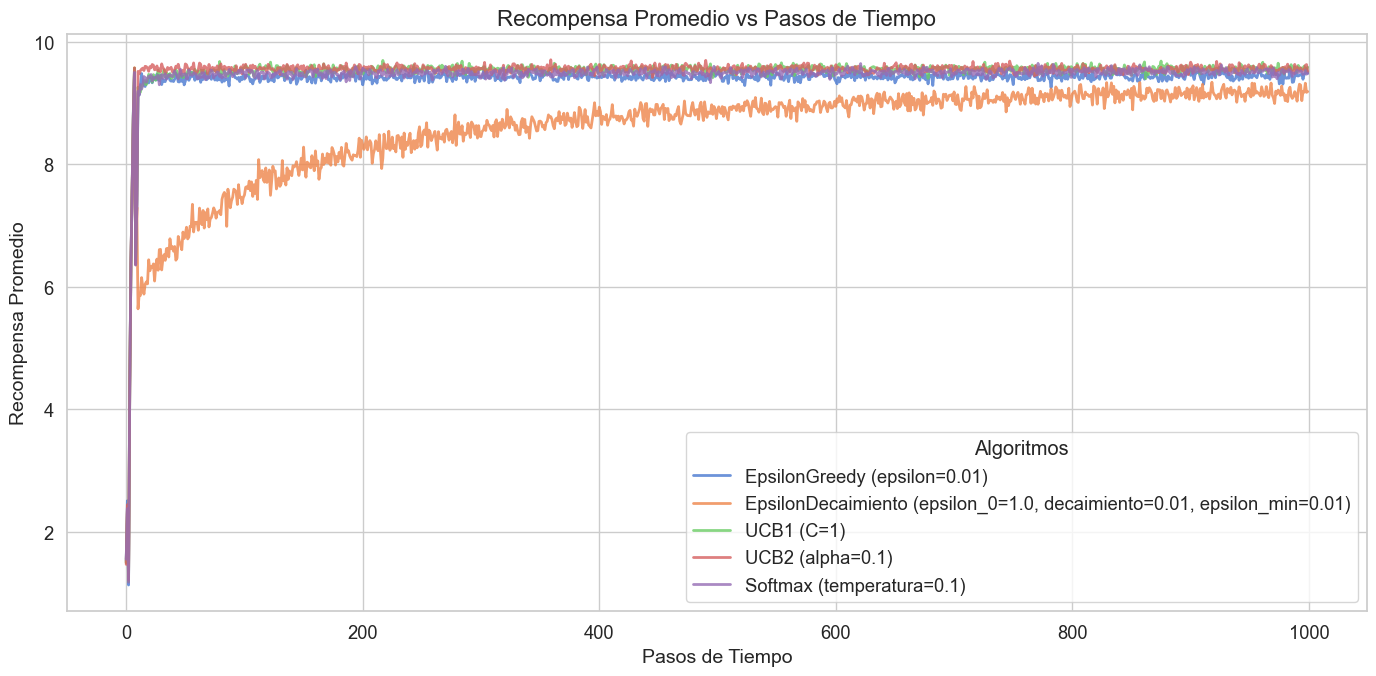

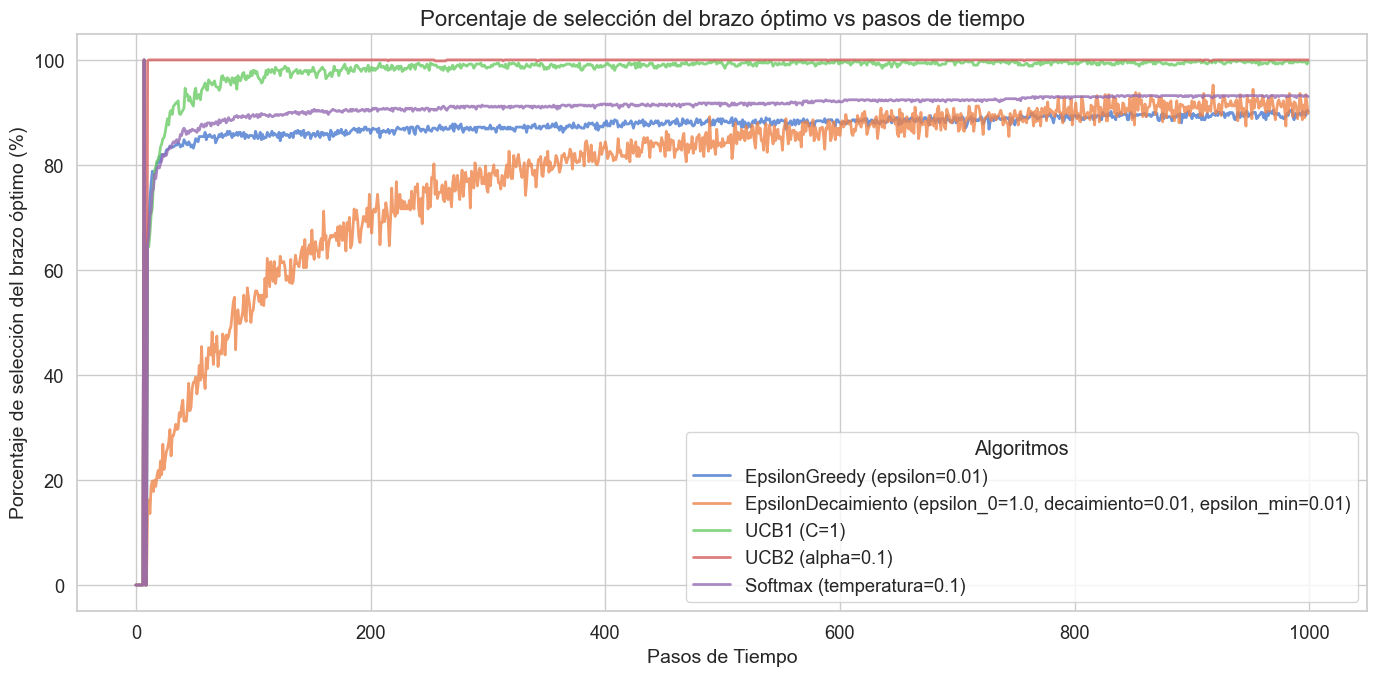

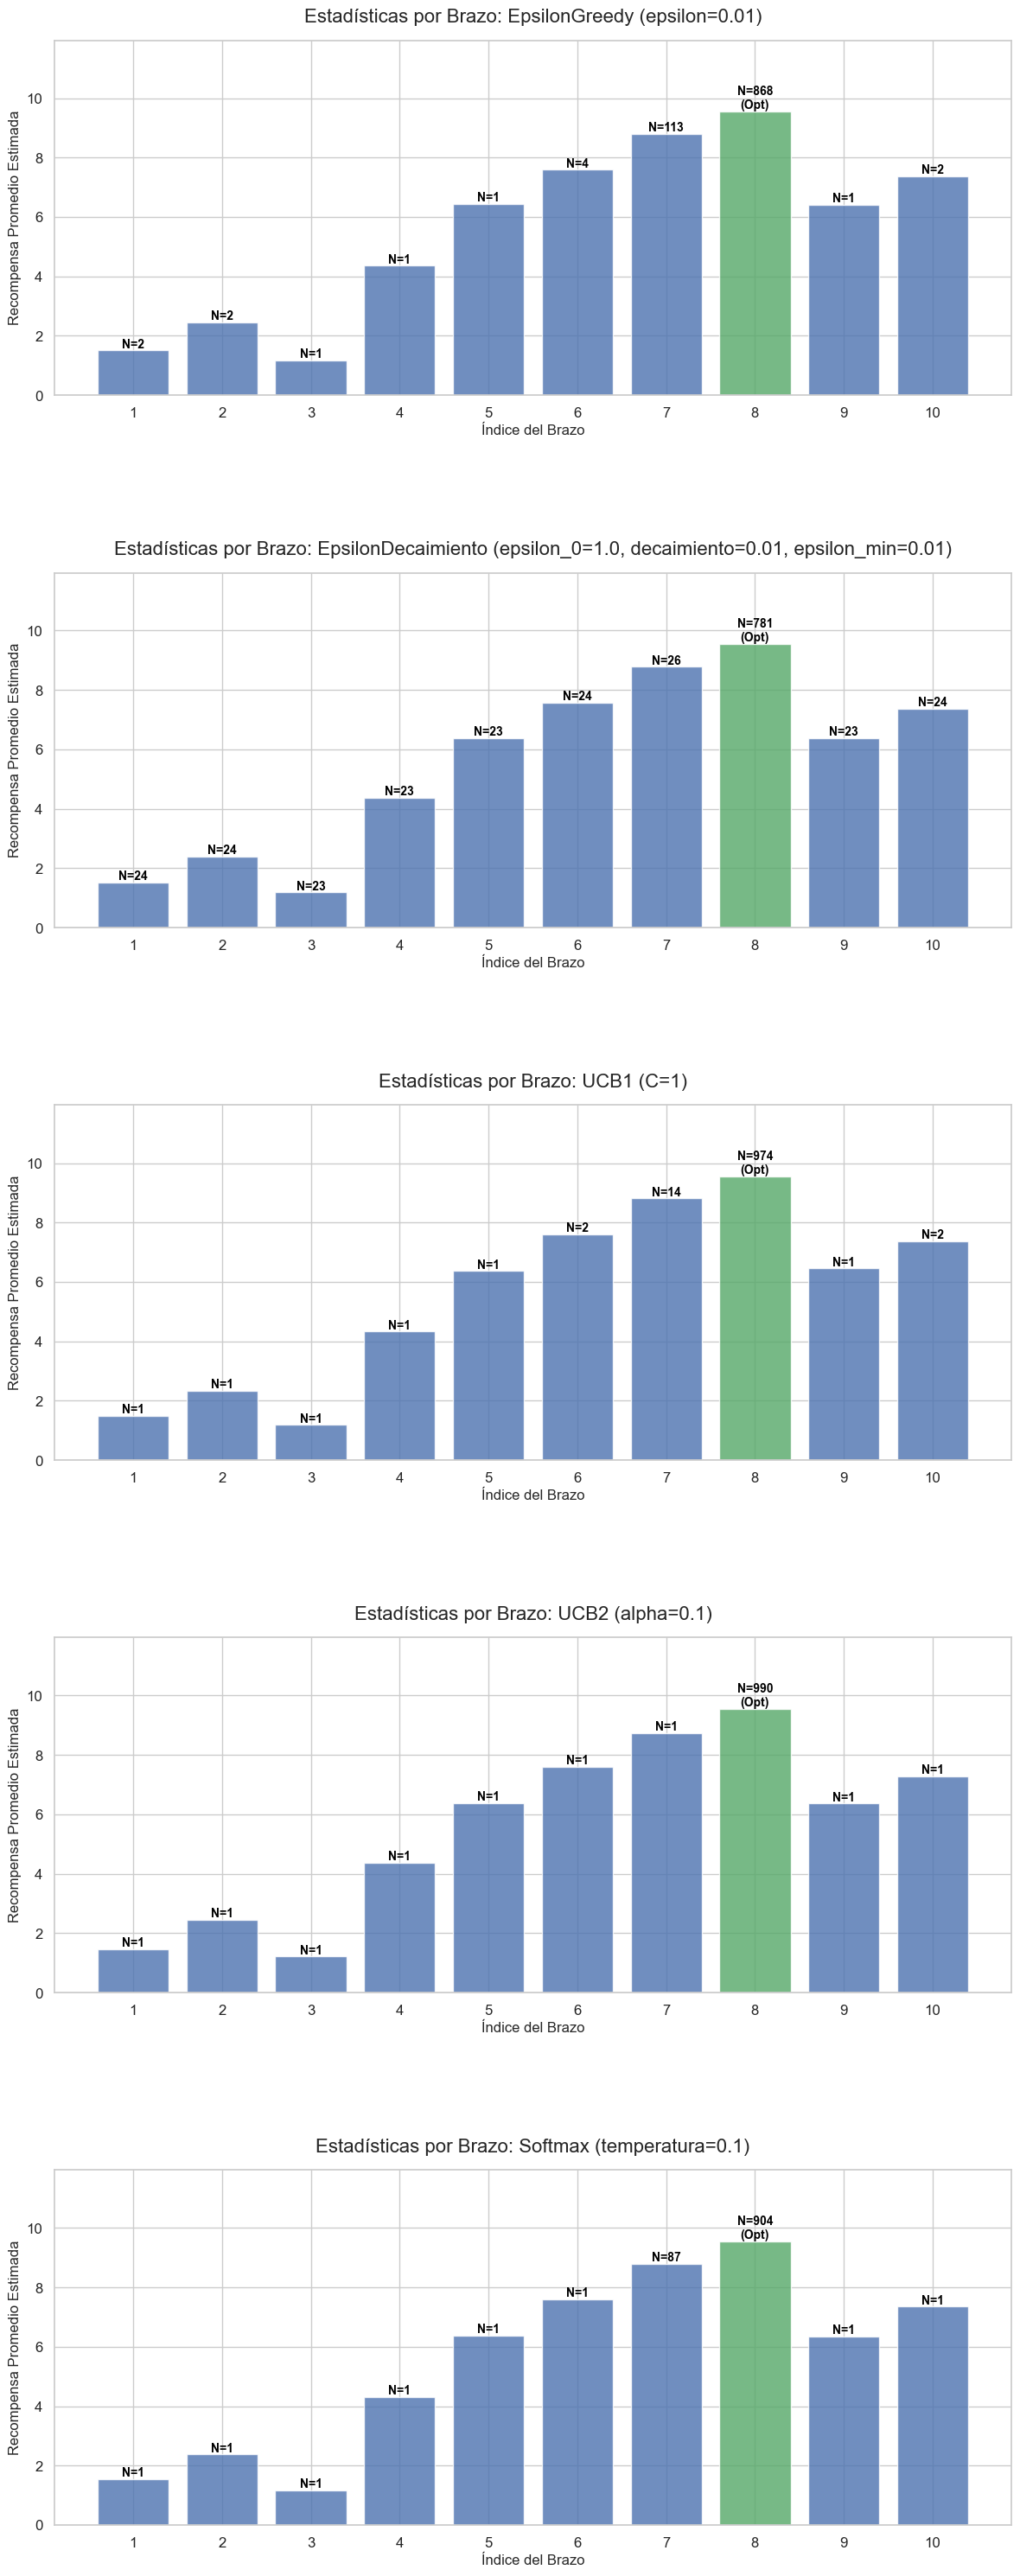

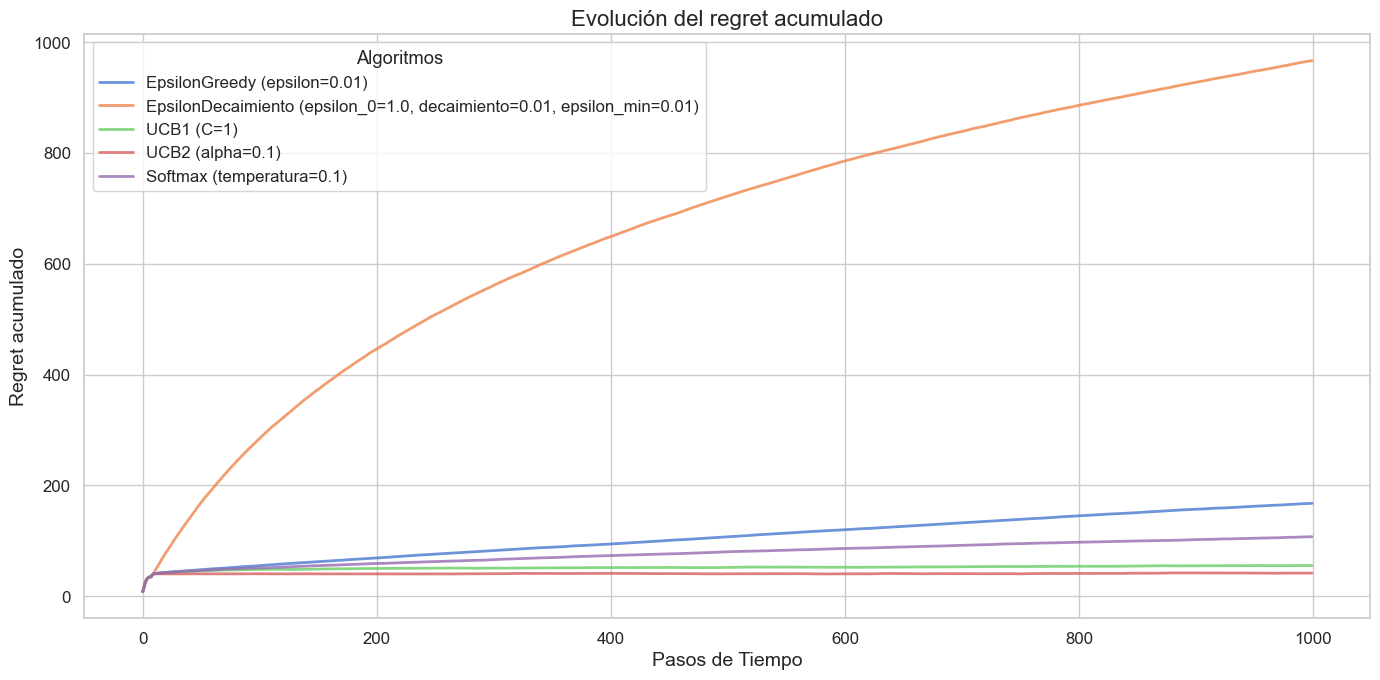

In [7]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis detallado de la imagen

En todas las gráficas de líneas aparecen **cinco curvas de colores distintos que representan los diferentes algoritmos $\epsilon$-Greedy, $\epsilon$-decaimiento, UCB1, UCB2 y Softmax**
   - **Azul ($\epsilon$ = 0.01):** Representa una estrategia con una probabilidad del 1% de elegir una acción aleatoria (exploración) y el 99% de elegir la acción con la mayor recompensa estimada (explotación).
   - **Naranja ($\epsilon$-decaimiento):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (UCB1):** Representa una estrategia basada en intervalos de confianza, que explora acciones poco exploradas de manera determinista.
   - **Rojo (UCB2):** Representa una estrategia similar a UCB1 pero con un enfoque más agresivo hacia la exploración, utilizando una función de crecimiento más rápida para el número de selecciones de cada acción.
   - **Morado (Softmax):** Representa una estrategia basada en una distribución de probabilidad de Boltzmann, donde la probabilidad de seleccionar cada acción depende de su valor estimado y una temperatura $\tau$ que controla el nivel de exploración.


#### Recompensa promedio vs pasos de tiempo

La primera imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **$\epsilon$-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo.

   - La línea **azul ($\epsilon$=0.01)** mantiene su recompensa promedio en un nivel alto. Esto se debe a que, antes de comenzar la explotación, el algoritmo realiza un recorrido inicial por todos los brazos para obtener estimaciones iniciales de sus recompensas. Gracias a ello, en la mayoría de las ejecuciones identifica rápidamente el brazo óptimo y lo explota durante el resto del tiempo. No obstante, este comportamiento depende fuertemente de de la estimación inicial.
   - La línea **naranja ($\epsilon$=0.01)** muestra un crecimiento de la recompensa promedio, pero más lento que para $\epsilon$=0.1, debido a su menor exploración.
   - La línea **verde ($\epsilon$=0.1)** alcanza rápidamente una recompensa promedio alta, lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos. Sin embargo, a largo plazo la recompensa promedio no puede superar aproximadamente el 90% del óptimo, ya que existe una probabilidad constante del 10% de seleccionar brazos subóptimos.
   - La línea **roja ($\epsilon$-decaimiento)** presenta un crecimiento inicial lento debido a su alta probabilidad de exploración al inicio. A medida que la probabilidad de exploración $\epsilon$ disminuye según la función de decaimiento inversamente proporcional $f(t,\epsilon_0,\lambda)=\frac{\epsilon_0}{1+\lambda t}$, la recompensa promedio se estabiliza en un nivel alto pues el algoritmo comienza a explotar más las opciones que han demostrado ser mejores, superando incluso a la estrategia con $\epsilon$=0.1 a largo plazo, ya que esta última sigue explorando con una probabilidad constante del 10% mientras que el $\epsilon$-decaimiento se queda con una probabilidad del 1%.
   
   Al final del proceso, todos los algoritmos convergen hacia la recompensa esperada del brazo óptimo (9.56), lo que indica que acaban identificándolo.
   
   En definitiva, con un número de pasos suficientemente grandes, los algoritmos de $\epsilon$-greedy con $\epsilon$=0.01 y $\epsilon$-decaimiento deberían coincidir, siendo los que mejor recompensas proporcionan. Dependiendo de la ejecución concreta, podría superar a $\epsilon$=0 o quedarse por debajo muy cerca de él. El que más rápido crece es $\epsilon$=0.1, pero a largo plazo se queda por debajo de los otros debido a su probabilidad de exploración del 10%.

#### Porcentaje de selección del brazo óptimo

La segunda gráfica, titulada **"Porcentaje de selección del brazo óptimo vs pasos de tiempo"**, se muestra un gráfico de líneas similar al anterior pero en este caso el eje **y** representa el **porcentaje de selección del brazo óptimo** a lo largo del tiempo. Este gráfico nos permite analizar cómo cada estrategia mejora su capacidad para identificar y seleccionar el brazo óptimo a medida que avanza el tiempo (como en todas las gráficas, promediado sobre las 500 runs). Aquí se observa claramente el efecto de $\epsilon$:

- $\epsilon$=0.1 aprende rápidamente cuál es el brazo óptimo, pero no puede superar el 90% de selección del brazo óptimo debido a su constante probabilidad de exploración. 
- $\epsilon$-decaimiento, que reduce su probabilidad de exploración con el tiempo, logra superar ese límite y acercarse al 100% de selección del brazo óptimo a largo plazo.
- $\epsilon$=0.01 muestra un comportamiento similar, aunque con una exploración menor. 
- $\epsilon$=0 depende completamente de la estimación inicial: si esta es correcta, puede alcanzar el 100% de selección casi inmediatamente; si es errónea, queda atrapado en una mala elección durante toda la ejecución. 

#### Estadísticas por brazo 

Lo anterior se ve reforzado por el gráfico **"Estadísticas por brazo"**, que muestra un histograma donde, para cada brazo, se representa el número de veces que ha sido seleccionado a lo largo de los 1000 pasos de tiempo (promediado sobre las 500 ejecuciones), y en el eje **y** la recompensa promedio obtenida por dicho brazo, la cual se aproxima a su valor esperado.

En el caso del algoritmo con $\epsilon = 0$, se observa que aproximadamente el 87% de las ejecuciones logran identificar el brazo óptimo desde el inicio, mientras que el 13% restante queda atrapado en una elección subóptima y no llega a identificar el brazo óptimo en ningún momento. Dado que, dentro de una misma ejecución, una vez que el algoritmo explotador selecciona un brazo continúa eligiéndolo de forma determinista, el histograma refleja directamente esta proporción: el brazo óptimo es seleccionado el 87.3% de las veces y el resto de los brazos concentra el 13% restante.

En los demás algoritmos, la exploración juega un papel más relevante dentro de cada ejecución, por lo que el histograma refleja la tasa de selección asociada a cada valor de $\epsilon$. En particular, el algoritmo con $\epsilon = 0.1$ y $\epsilon = 0.01$ son similares al de $\epsilon = 0$, pero en este caso debido a la estimación inicial, aunque para un número de pasos suficientemente grande deberían tender al 90% y 99%, respectivamente. Por otro lado,el algoritmo $\epsilon$-decaimiento presenta el peor resultado medio, debido a su elevada tasa de exploración inicial, que reduce su frecuencia de selección del brazo óptimo y, en consecuencia, su recompensa promedio.

#### Regret acumulado

La última gráfica, **"Evolución del regret acumulado"**, muestra un gráfico de líneas en el que se representa la evolución del regret acumulado a lo largo del tiempo para cada algoritmo. El regret acumulado se calcula como la diferencia entre la recompensa que se habría obtenido si siempre se hubiera elegido el brazo óptimo y la recompensa realmente obtenida por el algoritmo (la recompensa esperada del brazo seleccionado). 

Inicialmente, el regret crece más rápido para los algoritmos con mayor exploración ($\epsilon$ = 0.1 y $\epsilon$-decaimiento). Sin embargo, a largo plazo, el crecimiento del regret se estabiliza para todos los algoritmos, indicando que todos logran identificar el brazo óptimo. No obstante, no llegan a ser del todo estables porque en los algoritmos con $\epsilon$ distinto de cero, el regret sigue aumentando lentamente debido al porcentaje exploración.





## Conclusiones

Hemos estudiado un **experimento de toma de decisiones secuenciales**, modelado mediante un **Multi-Armed Bandit (MAB)**, un problema fundamental en aprendizaje por refuerzo y teoría de la decisión. En este contexto, un agente debe aprender cuál es la mejor acción (brazo) a partir de la experiencia acumulada, enfrentándose al compromiso entre exploración y explotación. En este trabajo nos hemos centrado exclusivamente en el análisis del algoritmo **$\epsilon$-greedy** y su variante con **$\epsilon$-decaimiento**, extrayendo las siguientes conclusiones a partir de los resultados experimentales obtenidos en las tres distribuciones de recompensa estudiadas.

### **1. Exploración vs Explotación**

El algoritmo **$\epsilon$-Greedy** permite controlar explícitamente el equilibrio entre exploración y explotación:

* **Explotación pura ($\epsilon$ = 0):** Selecciona siempre el brazo con mejor recompensa estimada. En nuestro caso, su buen desempeño se debe a la exploración inicial forzada de todos los brazos, que permite obtener una estimación inicial razonable. No obstante, su rendimiento sigue dependiendo críticamente de dicha estimación: si esta es incorrecta, el algoritmo puede quedar atrapado en un brazo subóptimo durante toda la ejecución.
* **Exploración ($\epsilon$ > 0):** Introduce aleatoriedad en la selección de acciones, lo que permite corregir estimaciones erróneas y descubrir brazos mejores a lo largo del tiempo.

Los resultados muestran que:

* **$\epsilon$ = 0.1 (verde)** aprende más rápido en las primeras etapas gracias a su elevada exploración, especialmente en distribuciones menos ruidosas.
* **$\epsilon$ = 0.01 (naranja)** presenta una convergencia más lenta, pero logra mejores resultados a largo plazo al reducir la exploración innecesaria.
* **$\epsilon$ = 0 (azul)** puede obtener muy buenos resultados si la estimación inicial es acertada, pero presenta una alta varianza entre ejecuciones y un riesgo significativo de estancamiento, especialmente en distribuciones ruidosas como la Bernoulli.

### **2. Convergencia y comportamiento a largo plazo**

Los algoritmos con mayor exploración convergen más rápidamente hacia el brazo óptimo, ya que compensan la falta de información inicial. Sin embargo, mantener una exploración constante penaliza el rendimiento a largo plazo:

* **$\epsilon$ = 0.1** se estanca por debajo del óptimo debido a su exploración permanente.
* **$\epsilon$ = 0.01** alcanza una recompensa cercana al óptimo con suficiente número de pasos.
* **$\epsilon$-decaimiento** combina las ventajas de ambos enfoques: explora intensamente al inicio y reduce progresivamente la exploración, lo que le permite **superar a $\epsilon$ = 0.1 y alcanzar el mejor rendimiento a largo plazo** en todos los experimentos.

Este comportamiento se confirma tanto en la recompensa promedio como en el porcentaje de selección del brazo óptimo y en la evolución del regret acumulado.

### **3. Influencia de la distribución de recompensas**

El desempeño relativo de los algoritmos depende de forma clara de la **variabilidad de la distribución de recompensas**:

* En la **distribución normal**, todos los algoritmos identifican el brazo óptimo con relativa facilidad.
* En la **distribución de Bernoulli**, la alta varianza y los empates iniciales penalizan especialmente a los algoritmos con poca exploración, haciendo que $\epsilon$-decaimiento resulte claramente superior a largo plazo.
* En la **distribución binomial**, la menor varianza facilita la convergencia de todos los algoritmos.

Esto pone de manifiesto que **cuanto mayor es el ruido de las recompensas, más importante resulta mantener mecanismos de exploración**.

### **4. Aplicaciones y conclusiones finales**

* En problemas de toma de decisiones (ejemplo: recomendaciones, optimización de anuncios, medicina personalizada), una estrategia con **exploración adaptativa**, como **$\epsilon$-decaimiento**, resulta más robusta y eficiente.
* La ausencia total de exploración ($\epsilon$ = 0) solo es recomendable cuando se dispone de una buena estimación inicial o de conocimiento previo del entorno.
* Mantener una exploración constante elevada ($\epsilon$ grande) permite aprender rápido, pero penaliza el rendimiento a largo plazo.

En conclusión, los experimentos muestran que **el equilibrio entre exploración y explotación es clave**, y que el algoritmo **$\epsilon$-greedy con decaimiento** ofrece, junto al $\epsilon$-greedy con $\epsilon=0.01$ el mejor compromiso global en entornos con incertidumbre, maximizando la recompensa a largo plazo y minimizando el regret acumulado.